In [1]:
#PREDICTING OPTIMAL GPU CONFIGURATION FOR DISCRETE FOURIER TRANSFORM
# Jackson Oleson - jo1449@nyu.edu

In [1]:
import numpy as np
np.set_printoptions(suppress=True, precision=6)
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor



/Users/yu/.pyenv/versions/3.9.18/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

#LOAD/PREPROCESS DATA
data = pd.read_excel("combined_convdata.xlsx")

# data = pd.read_csv("dftDataCuda2.csv")

X = data.drop('time', axis=1)
y = data['time']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_log = np.log(y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

cols = ['image_size', 'kernel_size', 'blocks', 'threadsPerBlock', 'mode',
       'total global memory(KB)', 'clock rate(KHz)',
       'multiprocessor count', 'async engine count', 'memory bus width',
       'memory clock rate (KHz)', 'L2 cache size (bytes)',
       'max threads per SM', 'time']

features = ['image_size', 'kernel_size', 'blocks', 'threadsPerBlock', 'mode',
       'total global memory(KB)', 'clock rate(KHz)', 'multiprocessor count',
       'async engine count', 'memory bus width', 'memory clock rate (KHz)',
       'L2 cache size (bytes)', 'max threads per SM']

cuda_cols = ['total global memory(KB)', 'clock rate(KHz)',
       'multiprocessor count', 'async engine count', 'memory bus width',
       'memory clock rate (KHz)', 'L2 cache size (bytes)',
       'max threads per SM']

device_specs = data[cuda_cols].drop_duplicates().to_numpy()

# device_specs[0] = cuda2
#device_specs[1] = cuda3
#device_specs[2] = cuda4
#device_specs[3] = cuda5

In [93]:
data.shape

(11076, 14)

In [3]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor(
#     n_estimators=100,       # Number of trees, comparable to XGBoost's `n_estimators`
#     max_depth=10,            # Limit depth to control model complexity
#     min_samples_split=2,    # Regularization similar to Decision Tree
#     min_samples_leaf=2,     # Regularization similar to Decision Tree
#     max_features='sqrt',    # Limit features per split (default is 'sqrt')
#     bootstrap=True,         # Random sampling with replacement
#     random_state=42
# )

# model = DecisionTreeRegressor(
#     max_depth=5,         # Limit tree depth for simplicity and to avoid overfitting
#     min_samples_split=5, # Minimum samples required to split an internal node
#     min_samples_leaf=3,  # Minimum samples required to be at a leaf node
#     random_state=42
# )
model = XGBRegressor(
    n_estimators=10000,        # Reduce the number of trees
    max_depth=8,            # Minimal tree depth
    learning_rate=0.1,     # Decrease learning rate
    # reg_alpha=1.0,          # Add L1 regularization
    # reg_lambda=1.0,         # Add L2 regularization
    # subsample=0.8,
    # colsample_bytree=1, 
    random_state=42
)
model.fit(X_train, y_log) #train on y_log instead of y_train to restrict the predicted compute times to be >0

preds_log = model.predict(X_test)
preds = np.exp(preds_log) #revert back from log of predicted time
preds[:6], y_test.to_numpy()[:6]

(array([  207.80365,  1029.1604 ,   143.79018,    77.94008, 35925.29   ,
          302.73383], dtype=float32),
 array([  179.464,  1028.   ,   143.18 ,    77.32 , 41382.8  ,   295.321]))

In [48]:
# Normalize time and predictions as a percentage of the maximum execution time for each "problem_size"
X_test["time"] = y_test
X_test["pred"] = preds
# Group by "problem_size" and compute normalization factor (max)
grouped_max_time = X_test.groupby("image_size")["time"].transform("max")

# Normalize actual time as a percentage of the max
X_test["normalized_time"] = (X_test["time"] / grouped_max_time) * 100

# Group by "problem_size" and compute normalization factor (max) for predictions
grouped_max_preds = X_test.groupby("image_size")["pred"].transform("max")

# Normalize predictions as a percentage of the max
X_test["normalized_pred"] = (X_test["pred"] / grouped_max_time) * 100

# Extract normalized predictions as a NumPy array (if needed)
normalized_preds = X_test["normalized_pred"].values

# # Calculate absolute error
# X_test["absolute_error"] = np.abs(X_test["normalized_pred"] - X_test["normalized_time"])

# # Group by "problem_size" and calculate MAE
# mae_by_group = X_test.groupby("image_size")["absolute_error"].mean()

# # Convert results to a DataFrame for display
# mae_results = mae_by_group.reset_index()
# mae_results.columns = ["image_size", "MAE"]

# # Display the results
# print(mae_results)


In [66]:
X_test['blocks_threads'] = X_test['blocks'] * X_test['threadsPerBlock']

# Sorting first by blocks * threadsPerBlock, then by image_size and kernel_size
sorted_df = X_test.sort_values(by=['blocks_threads', 'image_size', 'kernel_size'], ascending=[True, True, True]).reset_index(drop=True)


sorted_df.head()


,image_size,kernel_size,blocks,threadsPerBlock,mode,total global memory(KB),clock rate(KHz),multiprocessor count,async engine count,memory bus width,memory clock rate (KHz),L2 cache size (bytes),max threads per SM,time,normalized_time,pred,normalized_pred,absolute_error,blocks_threads
0,4,3,0,0,1,11269608,1635000,68,3,352,7000000,5767168,1024,0.003,0.001329,0.003317,0.001469,0.000067,0
1,4,7,0,0,1,12289920,2505000,46,2,192,10501000,37748736,1536,0.002,0.000886,0.002670,0.001182,0.000237,0
2,16,3,0,0,1,11269608,1635000,68,3,352,7000000,5767168,1024,0.025,0.008023,0.032914,0.010563,0.001081,0
3,16,7,0,0,1,12492800,1215500,24,2,384,3505000,3145728,2048,0.061,0.019577,0.063507,0.020381,0.002010,0
4,16,7,0,0,1,11269608,1635000,68,3,352,7000000,5767168,1024,0.064,0.020539,0.064896,0.020827,0.002589,0


In [92]:
sorted_df['threadsPerBlock'].unique()

array([   0,    8,   16,   32,   64,  128,  256,  512, 1024, 2048, 4096])

In [ ]:
sorted_df['image_size'].unique()

In [69]:
sorted_df1024 = sorted_df[sorted_df['image_size']==1024]

sorted_aggregated_df = sorted_df.groupby(["image_size",'blocks_threads']).mean().reset_index()
sorted_df1024aggregated_df = sorted_df1024.groupby(["image_size",'blocks_threads']).mean().reset_index()


In [77]:
# remove cpu mode
sorted_df1024aggregated_df = sorted_df1024aggregated_df[sorted_df1024aggregated_df['mode']==2]
sorted_df1024aggregated_df

,image_size,blocks_threads,kernel_size,blocks,threadsPerBlock,mode,total global memory(KB),clock rate(KHz),multiprocessor count,async engine count,memory bus width,memory clock rate (KHz),L2 cache size (bytes),max threads per SM,time,normalized_time,pred,normalized_pred,absolute_error
1,1024,128,3.000000,16.000000,8.000000,2.0,1.233926e+07,1.455000e+06,80.000000,7.000000,3072.000000,8.500000e+05,4.718592e+06,2048.000000,171.878000,28.507313,174.515244,28.944720,0.134287
2,1024,256,5.222222,23.111111,12.444444,2.0,1.223808e+07,1.771778e+06,54.888889,3.777778,1212.444444,5.340333e+06,1.549562e+07,1763.555556,158.340889,26.262077,158.982468,26.368487,1.377258
3,1024,512,6.600000,19.200000,28.800000,2.0,1.238094e+07,1.779200e+06,44.000000,3.000000,844.800000,5.772400e+06,1.730150e+07,1843.200000,148.016200,24.549646,147.133255,24.403202,1.240136
4,1024,1024,4.777778,76.444444,23.111111,2.0,1.227769e+07,1.601889e+06,46.222222,3.222222,935.111111,4.858000e+06,1.147608e+07,1820.444444,135.246556,22.431701,136.216980,22.592653,1.290245
5,1024,2048,5.000000,61.333333,68.666667,2.0,1.202978e+07,1.522667e+06,54.500000,3.583333,1029.333333,4.589250e+06,7.296341e+06,1664.000000,141.529167,23.473721,141.794647,23.517753,0.318735
6,1024,4096,5.428571,142.857143,77.714286,2.0,1.213630e+07,1.800143e+06,49.285714,2.928571,692.571429,6.373214e+06,1.629038e+07,1645.714286,150.620429,24.981578,156.663712,25.983904,1.797030
7,1024,8192,5.000000,114.526316,254.315789,2.0,1.211725e+07,1.744000e+06,62.631579,4.315789,1458.526316,4.963947e+06,1.346592e+07,1697.684211,166.663000,27.642364,170.697128,28.311456,0.863703
8,1024,16384,4.733333,347.733333,248.533333,2.0,1.213301e+07,1.933100e+06,50.533333,2.866667,646.400000,7.114800e+06,2.002780e+07,1604.266667,183.025800,30.356263,186.942642,31.005902,2.266505
9,1024,32768,4.714286,317.714286,649.142857,2.0,1.193961e+07,1.789357e+06,57.714286,3.333333,828.952381,6.329571e+06,1.433054e+07,1511.619048,166.718619,27.651589,164.306213,27.251472,1.658950
10,1024,65536,5.333333,300.444444,1543.111111,2.0,1.198332e+07,1.838389e+06,58.444444,3.444444,906.666667,6.412000e+06,1.590340e+07,1536.000000,160.680111,26.650055,171.855652,28.503607,2.230781


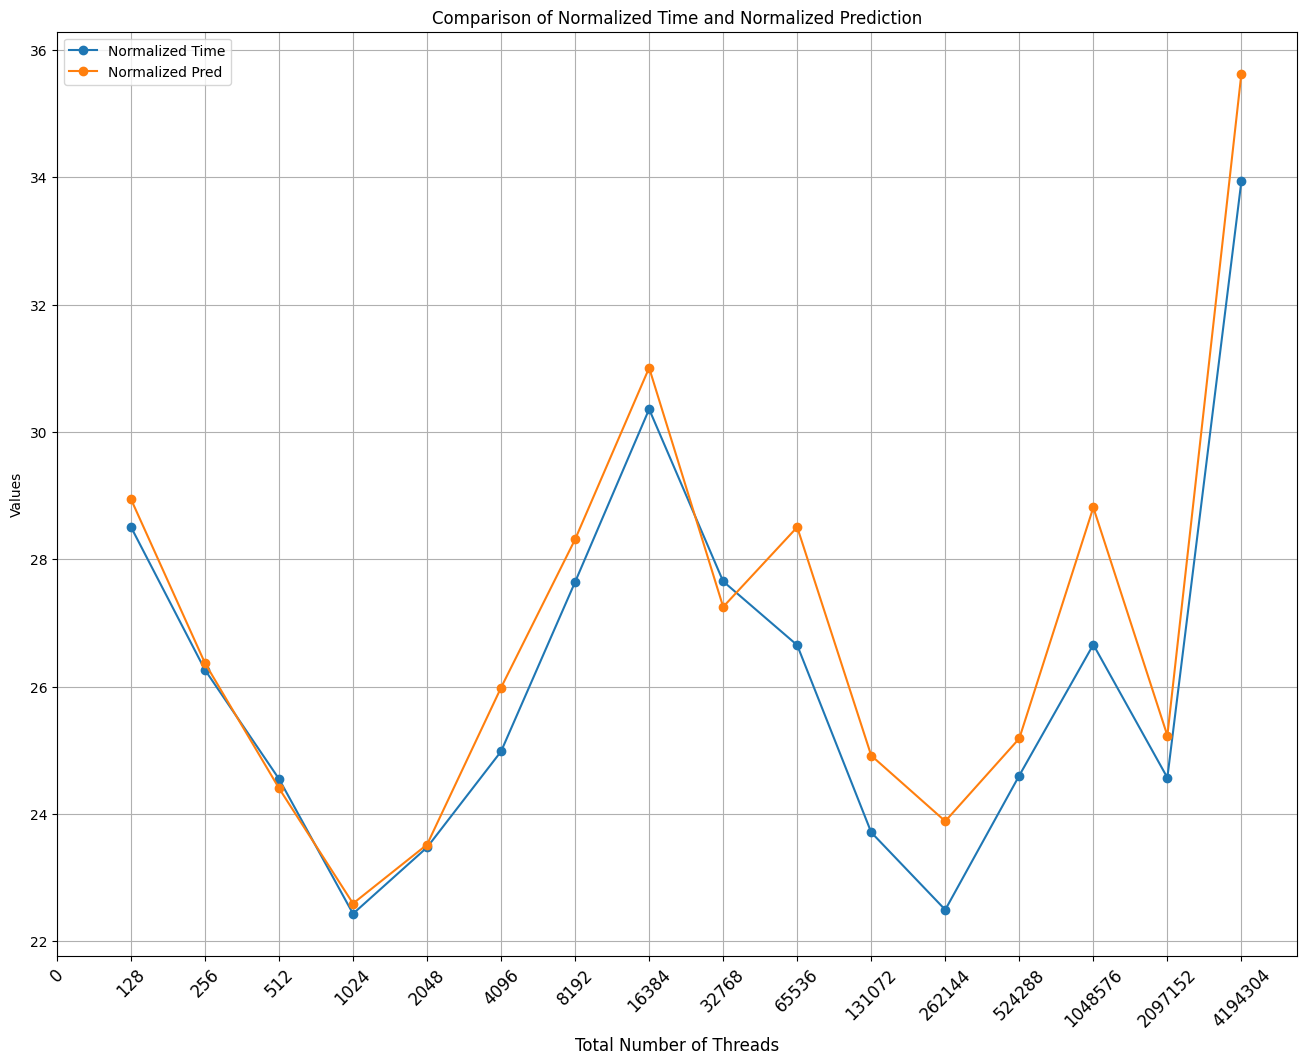

In [101]:
# Plotting the comparison
plt.figure(figsize=(16, 12))
plt.plot(sorted_df1024aggregated_df['normalized_time'], label='Normalized Time', marker='o')
plt.plot(sorted_df1024aggregated_df['normalized_pred'], label='Normalized Pred', marker='o')
plt.xlabel('Total Number of Threads', fontsize=12)
plt.xticks(range(1+len(sorted_df1024aggregated_df['blocks_threads'])), [0] + sorted_df1024aggregated_df['blocks_threads'].tolist(), fontsize=12, rotation=45)
# plt.xticks(ticks=sorted_df1024aggregated_df['blocks_threads'], labels="threads", )  # Attach x-axis labels

plt.ylabel('Values')
plt.title('Comparison of Normalized Time and Normalized Prediction')
plt.legend()
plt.grid(True)
# plt.show()

plt.savefig('comparison.png')

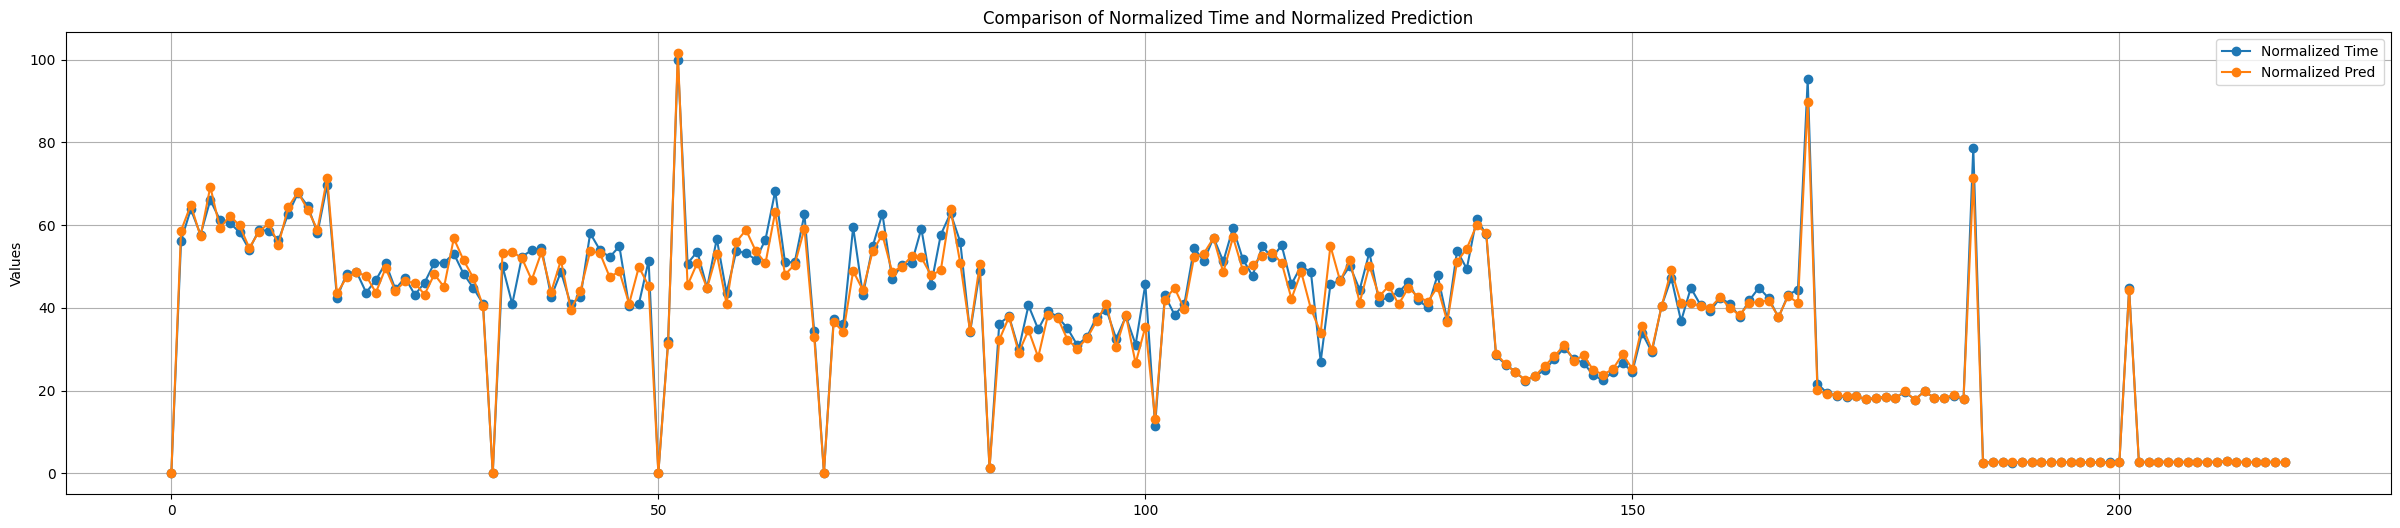

In [72]:
# Plotting the comparison
plt.figure(figsize=(30, 6))
plt.plot(sorted_aggregated_df['normalized_time'], label='Normalized Time', marker='o')
plt.plot(sorted_aggregated_df['normalized_pred'], label='Normalized Pred', marker='o')
# plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison of Normalized Time and Normalized Prediction')
plt.legend()
plt.grid(True)
plt.show()

In [108]:
blocks = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024])
# kernel_sizes=np.array([3, 5, 7, 9])
threads = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192])
image_sizes=np.array([256, 512, 1024, 2048, 4096, 8192, 16384])
modes = np.array([1, 2])
image_sizes = 16384.0

results = []
k, m = 3, 2
for b in blocks:
    for t in threads:

        #concatenate [elements, blocks, TPB] with rest of inputs (8,)
        #try with device_specs[x], x \in {0, 1, 2, 3}
        input_features = np.concatenate([np.array([image_sizes, k, b, t, m], dtype='float64'), device_specs[1]]).reshape(-1, 13)
        # input_features = scaler.fit_transform(input_features)
        #model was trained on log values, need to exponentiate once prediction is made
        res = np.exp(model.predict(input_features))

        results.append([b, t, res[0]])

results = np.array(results)
sorted = results[results[:, 2].argsort()] #sort array to determine the number of blocks and TPB with lowest runtimes 

min_b, min_tpb, min_time = results[np.argmin(results[:, 2])]
print(f'Best Config:')
print(f'Blocks: {int(min_b)} | Threads Per Block: {int(min_tpb)} | Time: {min_time:.6f}s')

Best Config:
Blocks: 16 | Threads Per Block: 16 | Time: 4315.376465s


In [109]:
print('Top 10 Best Configurations:')

for s in range(50):
    nb, tpb, time = sorted[s]
    print(f'Blocks: {int(nb)} | Threads Per Block: {int(tpb)} | Time: {time:.6f}s')

#Compare with test set
sorted_df = data[(data['image_size'] == image_sizes)].sort_values(by='time')
sorted_df.head(10)

Top 10 Best Configurations:
Blocks: 16 | Threads Per Block: 16 | Time: 4315.376465s
Blocks: 16 | Threads Per Block: 32 | Time: 4329.395508s
Blocks: 64 | Threads Per Block: 512 | Time: 4329.569336s
Blocks: 64 | Threads Per Block: 4096 | Time: 4337.103027s
Blocks: 64 | Threads Per Block: 8192 | Time: 4337.103027s
Blocks: 64 | Threads Per Block: 1024 | Time: 4339.395020s
Blocks: 16 | Threads Per Block: 4 | Time: 4348.708008s
Blocks: 16 | Threads Per Block: 8 | Time: 4348.708008s
Blocks: 1024 | Threads Per Block: 512 | Time: 4357.271973s
Blocks: 128 | Threads Per Block: 1024 | Time: 4361.762207s
Blocks: 16 | Threads Per Block: 64 | Time: 4361.783203s
Blocks: 128 | Threads Per Block: 32 | Time: 4364.937500s
Blocks: 256 | Threads Per Block: 512 | Time: 4367.527344s
Blocks: 1024 | Threads Per Block: 1024 | Time: 4368.793457s
Blocks: 256 | Threads Per Block: 1024 | Time: 4372.319824s
Blocks: 128 | Threads Per Block: 4096 | Time: 4375.602539s
Blocks: 128 | Threads Per Block: 8192 | Time: 4375.6

,image_size,kernel_size,blocks,threadsPerBlock,mode,time,total global memory(KB),clock rate(KHz),multiprocessor count,async engine count,memory bus width,memory clock rate (KHz),L2 cache size (bytes),max threads per SM
2603,16384,3,256,512,2,4010.38,11269608,1635000,68,3,352,7000000,5767168,1024
2744,16384,7,256,256,2,4014.18,11269608,1635000,68,3,352,7000000,5767168,1024
2584,16384,3,64,1024,2,4014.62,11269608,1635000,68,3,352,7000000,5767168,1024
2626,16384,3,1024,4096,2,4017.78,11269608,1635000,68,3,352,7000000,5767168,1024
2558,16384,3,16,16,2,4017.80,11269608,1635000,68,3,352,7000000,5767168,1024
2643,16384,5,32,256,2,4017.91,11269608,1635000,68,3,352,7000000,5767168,1024
2683,16384,5,512,256,2,4019.23,11269608,1635000,68,3,352,7000000,5767168,1024
2658,16384,5,128,8,2,4019.41,11269608,1635000,68,3,352,7000000,5767168,1024
2768,16384,7,1024,4096,2,4019.42,11269608,1635000,68,3,352,7000000,5767168,1024
2604,16384,3,256,1024,2,4020.03,11269608,1635000,68,3,352,7000000,5767168,1024


In [104]:
device_specs[1]
#Best GPU overall for this problem: cuda3

array([12339264,  1455000,       80,        7,     3072,   850000,
        4718592,     2048])

In [105]:
#Compare with Ground Truth for 100k Elements
# ground truth gathered by running many configurations of blocks and threadsPerBlock on CIMS servers
# with fixed number of elements for 20 iterations each and taking their mean stratified by configuration
# note: all GT configurations ran on the system with the best overall performance (cuda3 in this case)

gt = pd.read_csv('convGT.csv')
gt.drop([' mode', ' kernel_size'], axis=1, inplace=True)
gt = gt.groupby([' blocks', ' threadsPerBlock']).mean().reset_index().sort_values(' time(ms)')
gt = gt[gt[' time(ms)'] != 0]

gt.head(10)

,blocks,threadsPerBlock,image_size,time(ms)
26,64,512,16384.0,4365.76
67,1024,1024,16384.0,4370.59
64,1024,128,16384.0,4372.38
23,64,64,16384.0,4372.73
58,512,2048,16384.0,4373.35
39,128,4096,16384.0,4374.31
28,64,2048,16384.0,4374.86
31,128,16,16384.0,4375.73
41,256,16,16384.0,4376.02
59,512,4096,16384.0,4376.65


In [107]:
results = []
for idx, vals in gt.iterrows():    
    b, t = vals[' blocks'], vals[' threadsPerBlock']
    #concatenate [elements, blocks, TPB] with rest of inputs (8,)
    input_features = np.concatenate([np.array([image_sizes, 3, b, t, 2], dtype='float64'), device_specs[1]]).reshape(-1, 13)
    # input_features = scaler.fit_transform(input_features)
    #model was trained on log values, need to exponentiate once prediction is made
    res = np.exp(model.predict(input_features))

    results.append([b, t, res[0]])

print(results)

[[64.0, 512.0, 1105.9094], [1024.0, 1024.0, 1101.0072], [1024.0, 128.0, 1114.8479], [64.0, 64.0, 1116.6862], [512.0, 2048.0, 1114.0449], [128.0, 4096.0, 1112.2382], [64.0, 2048.0, 1110.7415], [128.0, 16.0, 1113.824], [256.0, 16.0, 1118.266], [512.0, 4096.0, 1117.2241], [64.0, 4096.0, 1106.8364], [512.0, 64.0, 1109.9685], [128.0, 64.0, 1113.908], [512.0, 512.0, 1116.2747], [32.0, 256.0, 1110.3501], [256.0, 64.0, 1114.5588], [256.0, 8.0, 1117.8198], [128.0, 512.0, 1114.555], [256.0, 32.0, 1115.7095], [256.0, 512.0, 1110.1632], [512.0, 128.0, 1118.426], [64.0, 1024.0, 1105.4176], [256.0, 4096.0, 1109.5155], [16.0, 128.0, 1121.1213], [512.0, 16.0, 1116.2932], [64.0, 32.0, 1117.7415], [64.0, 256.0, 1125.5131], [512.0, 32.0, 1102.7931], [1024.0, 4096.0, 1113.086], [2048.0, 128.0, 1114.8479], [64.0, 8.0, 1135.2421], [128.0, 8.0, 1110.777], [32.0, 128.0, 1111.2914], [1024.0, 256.0, 1118.2042], [16.0, 64.0, 1116.8208], [128.0, 256.0, 1114.3335], [16.0, 8.0, 1122.0557], [16.0, 512.0, 1125.6145],

In [ ]:
def analyze_feature_importance(model, X_train, exclude, feature_names=None):
    import shap
    
    if isinstance(exclude, str):
        exclude_idx = feature_names.index(exclude)
    else:
        exclude_idx = exclude
    
    include_names = [name for i, name in enumerate(feature_names) if i != exclude_idx]
    
    importance_values = model.feature_importances_
    importance_dict = {
        name: score for name, score in zip(
            feature_names, 
            importance_values
        ) if name != feature_names[exclude_idx]
    }
    
    importance_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Importance': list(importance_dict.values())
    }).sort_values('Importance', ascending=False)
    
    # Running SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    
    # Exclude 'elements'
    if isinstance(X_train, pd.DataFrame):
        X_train_filtered = X_train.drop(columns=[feature_names[exclude_idx]])
    else:
        X_train_filtered = np.delete(X_train, exclude_idx, axis=1)
    
    shap_values_filtered = np.delete(shap_values, exclude_idx, axis=1)

    # Ensure the lengths match
    
    assert shap_values_filtered.shape[1] == len(include_names), "Mismatch in SHAP filtered features and names"

    # Mean absolute SHAP values for each input feature
    mean_shap = pd.DataFrame({
        'Feature': include_names,
        'SHAP_Importance': np.abs(shap_values_filtered).mean(axis=0)
    }).sort_values('SHAP_Importance', ascending=False)
    

    fig_xgb = plt.figure(figsize=(10, 5))
    importance_df.plot(x='Feature', y='Importance', kind='bar')
    plt.title('XGBoost Feature Importance')
    plt.xlabel('Features')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=70)
    plt.tight_layout()
    
    fig_shap = plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values_filtered, X_train_filtered, 
                     feature_names=include_names, show=False)
    plt.title('SHAP Feature Importance')
    plt.tight_layout()
    
    return {
        'xgboost_importance': importance_df,
        'shap_importance': mean_shap,
        'shap_values': shap_values_filtered,
        'figure_xgb': fig_xgb,
        'figure_shap': fig_shap
    }

results = analyze_feature_importance(model, X_train, exclude='image_size', feature_names=features)

print("\nTop 5 most important features (XGBoost):")
print(results['xgboost_importance'].head())

print("\nTop 5 most important features (SHAP):")
print(results['shap_importance'].head())

plt.show()
